In [1]:
!pip install yt-dlp openai pillow opencv-python-headless numpy requests
!apt-get install fonts-dejavu-core -y
!pip install openai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-dejavu-core
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,041 kB of archives.
After this operation, 3,025 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Fetched 1,041 kB in 0s (12.8 MB/s)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-dejavu-core is already the newest version (2.37-2build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
[youtube] Extracting URL: https://www.youtube.com/watch?v=BxqTSdUFNaM
[youtube] BxqTSdUFNaM: Downloading webpage


[youtube] BxqTSdUFNaM: Downloading android vr player API JSON
[info] BxqTSdUFNaM: Downloading 1 format(s): 18
[download] Destination: downloaded_video.mp4
[download] 100% of   12.37MiB in 00:00:00 at 21.79MiB/s  
Video downloaded successfully!



Original Video Title:
Socceroos fans celebrate Australia's win against Türkiye in World Cup | ABC NEWS

AI Generated Thumbnail Text:
Socceroos Triumph Shocks Türkiye Fans
Extracting frames...
Logo could not load

Thumbnail generated successfully!
Saved as: awesome_thumbnail.jpg


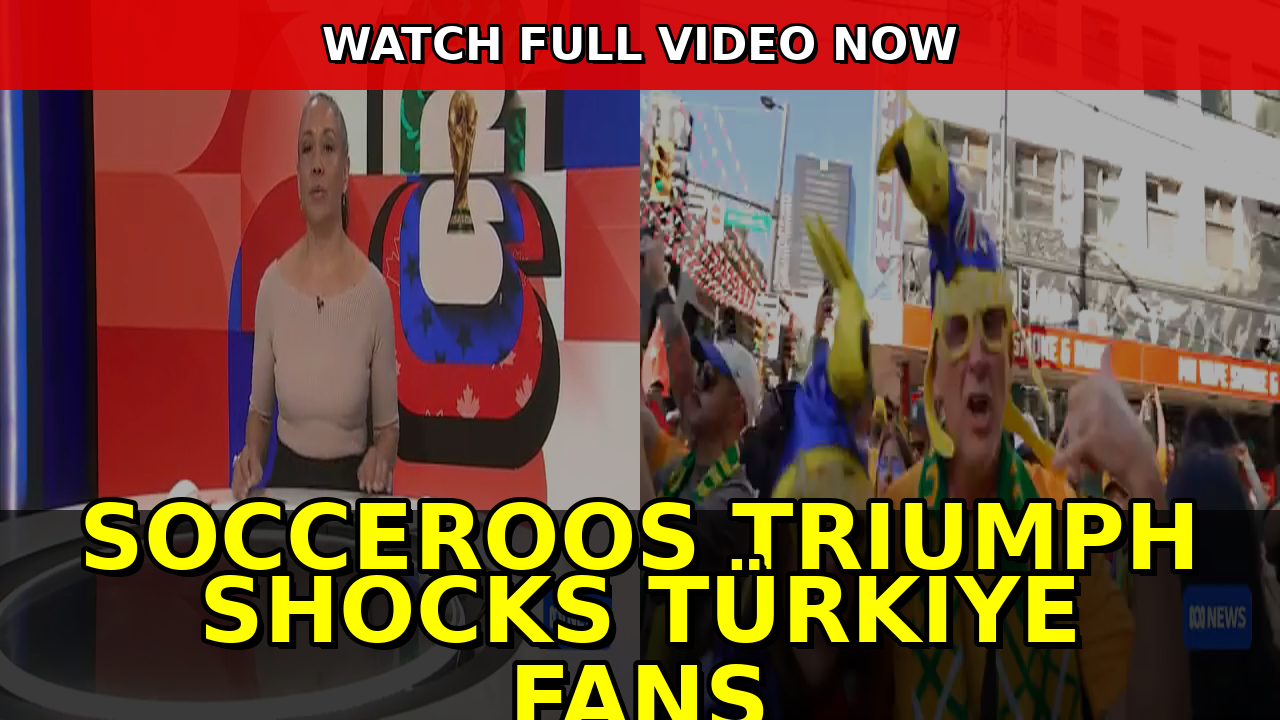

In [ ]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================

!apt-get install fonts-dejavu-core -y
!pip install yt-dlp pillow opencv-python-headless numpy requests openai -q


# ============================================================
# IMPORTS
# ============================================================

import os
import cv2
import yt_dlp
import numpy as np
import requests
import textwrap

from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
from openai import OpenAI


# ============================================================
# INPUT YOUTUBE VIDEO LINK
# ============================================================

YOUTUBE_URL = "https://www.youtube.com/watch?v=BxqTSdUFNaM"


# ============================================================
# DOWNLOAD VIDEO
# ============================================================

output_video = "downloaded_video.mp4"

ydl_opts = {
    'format': 'best[ext=mp4]',
    'outtmpl': output_video,
    'quiet': False
}

print("Downloading video...")

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([YOUTUBE_URL])

print("Video downloaded successfully!")


# ============================================================
# OPENAI API KEY
# ============================================================

OPENAI_API_KEY = "sk-proj-xxxxxxxxxxxxD4xxxxxxxxxxxxxxxxxF-cxxxxxxxxxxxxxxxxxxxxxxxA"

client = OpenAI(api_key=OPENAI_API_KEY)


# ============================================================
# GET YOUTUBE VIDEO TITLE
# ============================================================

with yt_dlp.YoutubeDL({'quiet': True}) as ydl:

    info = ydl.extract_info(YOUTUBE_URL, download=False)

    original_title = info.get("title", "")

print("\nOriginal Video Title:")
print(original_title)


# ============================================================
# AI TITLE REWRITER
# ============================================================

prompt = f"""
You are a professional YouTube thumbnail copywriter.

Your task:

1. Detect the language of the title.
2. If title is not English:
   translate it into English.
3. Rewrite into a powerful thumbnail headline.

Rules:
- Maximum 5 to 8 words
- Very clickable
- Emotional
- Clear meaning
- No emojis
- English only
- Output only final title

Original Title:
{original_title}
"""

response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],
    temperature=0.9
)

thumbnail_text = response.choices[0].message.content.strip()

print("\nAI Generated Thumbnail Text:")
print(thumbnail_text)


# ============================================================
# OPEN VIDEO
# ============================================================

cap = cv2.VideoCapture(output_video)

fps = cap.get(cv2.CAP_PROP_FPS)

if fps == 0:
    raise Exception("Could not read video")


# ============================================================
# EXTRACT FRAME FUNCTION
# ============================================================

def extract_frame(second):

    frame_number = int(fps * second)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    success, frame = cap.read()

    if not success:
        raise Exception(f"Could not extract frame at {second} sec")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    return Image.fromarray(frame)


# ============================================================
# EXTRACT FRAMES
# ============================================================

print("Extracting frames...")

frame1 = extract_frame(5)
frame2 = extract_frame(12)

cap.release()


# ============================================================
# RESIZE FRAMES
# ============================================================

frame_width = 640
frame_height = 720

frame1 = frame1.resize((frame_width, frame_height))
frame2 = frame2.resize((frame_width, frame_height))


# ============================================================
# CREATE THUMBNAIL
# ============================================================

final_width = 1280
final_height = 720

thumbnail = Image.new("RGB", (final_width, final_height), "black")

thumbnail.paste(frame1, (0, 0))
thumbnail.paste(frame2, (640, 0))


# ============================================================
# DARK OVERLAY
# ============================================================

overlay = Image.new(
    "RGBA",
    thumbnail.size,
    (0, 0, 0, 80)
)

thumbnail = Image.alpha_composite(
    thumbnail.convert("RGBA"),
    overlay
)

thumbnail = thumbnail.convert("RGB")


# ============================================================
# DRAW OBJECT
# ============================================================

draw = ImageDraw.Draw(thumbnail)


# ============================================================
# FONT SETTINGS
# ============================================================

font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"

main_font = ImageFont.truetype(font_path, 90)

top_font = ImageFont.truetype(font_path, 45)


# ============================================================
# TOP RED BAR
# ============================================================

top_bar_height = 90

top_bar = Image.new(
    "RGBA",
    (final_width, top_bar_height),
    (220, 0, 0, 230)
)

thumbnail.paste(
    top_bar,
    (0, 0),
    top_bar
)


# ============================================================
# TOP BAR TEXT
# ============================================================

top_text = "WATCH FULL VIDEO NOW"

bbox_top = draw.textbbox(
    (0, 0),
    top_text,
    font=top_font
)

top_width = bbox_top[2] - bbox_top[0]

x_top = (final_width - top_width) // 2
y_top = 18


for offset in range(1, 5):

    draw.text(
        (x_top + offset, y_top + offset),
        top_text,
        font=top_font,
        fill="black"
    )

draw.text(
    (x_top, y_top),
    top_text,
    font=top_font,
    fill="white",
    stroke_width=3,
    stroke_fill="black"
)


# ============================================================
# BOTTOM OVERLAY
# ============================================================

bottom_overlay_height = 210

bottom_overlay = Image.new(
    "RGBA",
    (final_width, bottom_overlay_height),
    (0, 0, 0, 170)
)

thumbnail.paste(
    bottom_overlay,
    (0, final_height - bottom_overlay_height),
    bottom_overlay
)


# ============================================================
# BOTTOM TITLE
# ============================================================

bottom_title = thumbnail_text.upper()

wrapped_bottom = textwrap.fill(
    bottom_title,
    width=18
)

lines = wrapped_bottom.split("\n")

line_spacing = 5

line_heights = []

for line in lines:

    bbox = draw.textbbox(
        (0, 0),
        line,
        font=main_font
    )

    line_height = bbox[3] - bbox[1]

    line_heights.append(line_height)

total_text_height = sum(line_heights) + (
    line_spacing * (len(lines) - 1)
)

y_bottom = final_height - total_text_height - 5


# ============================================================
# DRAW BOTTOM TEXT
# ============================================================

for i, line in enumerate(lines):

    bbox = draw.textbbox(
        (0, 0),
        line,
        font=main_font
    )

    line_width = bbox[2] - bbox[0]

    line_height = bbox[3] - bbox[1]

    x_line = (final_width - line_width) // 2

    # Shadow
    for offset in range(1, 8):

        draw.text(
            (x_line + offset, y_bottom + offset),
            line,
            font=main_font,
            fill="black"
        )

    # Main Text
    draw.text(
        (x_line, y_bottom),
        line,
        font=main_font,
        fill="yellow",
        stroke_width=5,
        stroke_fill="black"
    )

    y_bottom += line_height + line_spacing


# ============================================================
# OPTIONAL YOUTUBE LOGO
# ============================================================

logo_url = "https://upload.wikimedia.org/wikipedia/commons/7/75/YouTube_social_white_squircle_%282017%29.svg"

try:

    response = requests.get(logo_url)

    logo = Image.open(
        BytesIO(response.content)
    ).convert("RGBA")

    logo = logo.resize((120, 120))

    thumbnail.paste(
        logo,
        (final_width - 150, 100),
        logo
    )

except:

    print("Logo could not load")


# ============================================================
# SAVE THUMBNAIL
# ============================================================

output_thumbnail = "awesome_thumbnail.jpg"

thumbnail.save(
    output_thumbnail,
    quality=100
)

print("\nThumbnail generated successfully!")
print(f"Saved as: {output_thumbnail}")


# ============================================================
# SHOW THUMBNAIL
# ============================================================

thumbnail